# Revenue Project Analysis Notebook

This notebook helps you explore the revenue project data using Python.


In [15]:
import pandas as pd
import sqlite3
from pathlib import Path


In [17]:
base_path = Path('..') / 'data' / 'raw'


## Load CSV Files


In [20]:
customers = pd.read_csv(base_path / 'customers.csv')
orders = pd.read_csv(base_path / 'orders.csv')
products = pd.read_csv(base_path / 'products.csv')


## Load SQLite Database


In [21]:
conn = sqlite3.connect(base_path / 'revenue.db')


In [22]:
customers.to_sql('customers', conn, if_exists='replace', index=False)
orders.to_sql('orders', conn, if_exists='replace', index=False)
products.to_sql('products', conn, if_exists='replace', index=False)


20

## Sample Revenue Calculation


In [26]:
revenue_df = orders.merge(products, on='product_id', how='left')

revenue_df[['order_id', 'customer_id', 'product_id', 'revenue']].head()


,order_id,customer_id,product_id,revenue
0,1,88,12,744
1,2,95,13,2476
2,3,97,12,2728
3,4,87,4,1223
4,5,14,13,1344


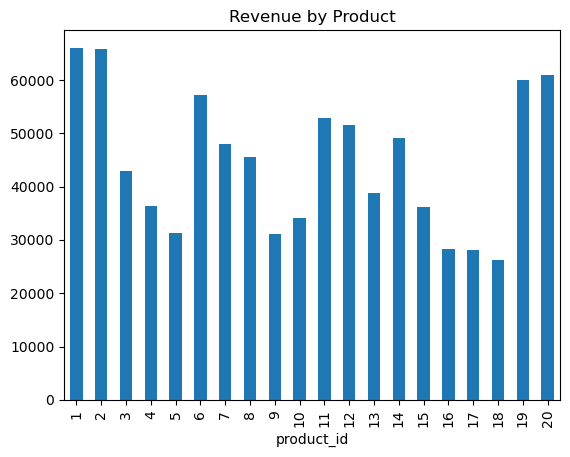

In [27]:
import matplotlib.pyplot as plt

revenue_df.groupby('product_id')['revenue'].sum().plot(kind='bar')
plt.title("Revenue by Product")
plt.show()
